# Homework 2: Supervised Learning 
Joshua Ng

## 1. Classification

In [257]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/homeworks/hw2/data/properties.csv", index_col=0)
compositions = pd.read_csv("https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/homeworks/hw2/data/compositions.csv", index_col=0)
X = compositions.values # inputs for ML models
y = df["beta"] # output property

df.head()

,id,eid,formula,R1,R2,R3,F1,F2,F3,P0,...,HV_err,moe,moe_class,ph1,ph2,ph3,condition,comments,composition,beta
0,1,Ti-23Nb-10Zr-2.0Fe,Ti0.7791Fe0.0234Zr0.0617Nb0.1358,1,10.1007/s10853-021-06002-0,salvador2021,1,0,0,1860.0,...,8.0,12.88,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7791 Fe0.0234 Zr0.0617 Nb0.1358,1
1,2,Ti-27Nb-10Zr-1.5Fe,Ti0.7575Fe0.0156Zr0.0637Nb0.1632,1,10.1007/s10853-021-06002-0,salvador2021,1,1,0,1400.0,...,2.0,11.65,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7575 Fe0.0156 Zr0.0637 Nb0.1632,1
2,3,Ti-31Nb-10Zr-1.0Fe,Ti0.7298Fe0.0138Zr0.0664Nb0.1899,1,10.1007/s10853-021-06002-0,salvador2021,1,0,0,1310.0,...,5.0,12.08,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7298 Fe0.0138 Zr0.0664 Nb0.1899,1
3,4,Ti-11Nb-7Zr-3.5Fe,Ti0.8622Fe0.0349Zr0.041Nb0.0618,2,10.1016/j.matdes.2018.10.040,dalbo2018,1,1,0,1640.0,...,3.0,13.78,meta,Ti-beta,Ti-omega,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.8622 Fe0.0349 Zr0.041 Nb0.0618,1
4,5,Ti-19Nb-6Sn-2.5Fe,Ti0.8376Fe0.0256Nb0.11Sn0.0268,2,10.1016/j.matdes.2018.10.040,dalbo2018,1,1,0,1280.0,...,9.0,12.76,meta,Ti-beta,Ti-omega,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.8376 Fe0.0256 Nb0.11 Sn0.0268,1


### 1.1 Training and Evaluating Classifiers

In [258]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
print(x_train.shape)
print(x_test.shape)


(226, 17)
(57, 17)


In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [260]:
models0 = {
    "logistic": LogisticRegression(),
    "SVC": SVC(probability=True),
    "tree": DecisionTreeClassifier(),
    "rf": RandomForestClassifier(),
    "knns": KNeighborsClassifier(),
    "xgboost": XGBClassifier()
}

results = {}

for name, model in models0.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate metrics
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    # Conditionally format roc_auc based on its type
    roc_auc_str = f"{roc_auc:.4f}" if isinstance(roc_auc, float) else str(roc_auc)
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC AUC: {roc_auc_str}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


Training logistic...
logistic - Accuracy: 0.8772, Precision: 0.8654, Recall: 1.0000, F1-score: 0.9278, ROC AUC: 0.8741

Training SVC...
SVC - Accuracy: 0.8947, Precision: 0.8824, Recall: 1.0000, F1-score: 0.9375, ROC AUC: 0.8593

Training tree...
tree - Accuracy: 0.8947, Precision: 0.9333, Recall: 0.9333, F1-score: 0.9333, ROC AUC: 0.8389

Training rf...
rf - Accuracy: 0.9298, Precision: 0.9362, Recall: 0.9778, F1-score: 0.9565, ROC AUC: 0.9259

Training knns...
knns - Accuracy: 0.8772, Precision: 0.9130, Recall: 0.9333, F1-score: 0.9231, ROC AUC: 0.8759

Training xgboost...
xgboost - Accuracy: 0.8947, Precision: 0.9149, Recall: 0.9556, F1-score: 0.9348, ROC AUC: 0.9278


,accuracy,precision,recall,f1_score,roc_auc
logistic,0.877193,0.865385,1.000000,0.927835,0.874074
SVC,0.894737,0.882353,1.000000,0.937500,0.859259
tree,0.894737,0.933333,0.933333,0.933333,0.838889
rf,0.929825,0.936170,0.977778,0.956522,0.925926
knns,0.877193,0.913043,0.933333,0.923077,0.875926
xgboost,0.894737,0.914894,0.955556,0.934783,0.927778


The dataset is quite small, so the models in general behaved quite similarly. Rf is the best models here by f1_score, but only marginally. 

### 1.2 Interpreting the Classifiers

In [261]:
cols = ['Ti', 'Fe', 'Zr', 'Nb', 'Sn', 'Ta', 'Mo', 'Al', 'V', 'Cr', 'Cu', 'Hf', 'Mn', 'W', 'Ni', 'Sc', 'Si']
col_to_idx = {name: i for i, name in enumerate(cols)}
percentages = np.arange(0.1, 51, 0.1)
num_rows = len(percentages)
num_cols = len(cols)

synthetic_dict = {}

for element in cols:
    if element == 'Ti':
        continue
    element_array = np.zeros((num_rows, num_cols))
    target_idx = col_to_idx[element]
    element_array[:, target_idx] = percentages
    element_array[:, 0] = 100 - percentages
    synthetic_dict[element] = element_array

# --- Verification ---
print(f"Keys available: {list(synthetic_dict.keys())}")
print(f"Shape of 'Fe' array: {synthetic_dict['Fe'].shape}")
print("\nFirst 3 rows of Fe series:")
print(synthetic_dict['Fe'][:3])

Keys available: ['Fe', 'Zr', 'Nb', 'Sn', 'Ta', 'Mo', 'Al', 'V', 'Cr', 'Cu', 'Hf', 'Mn', 'W', 'Ni', 'Sc', 'Si']
Shape of 'Fe' array: (509, 17)

First 3 rows of Fe series:
[[99.9  0.1  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]
 [99.8  0.2  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]
 [99.7  0.3  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]]


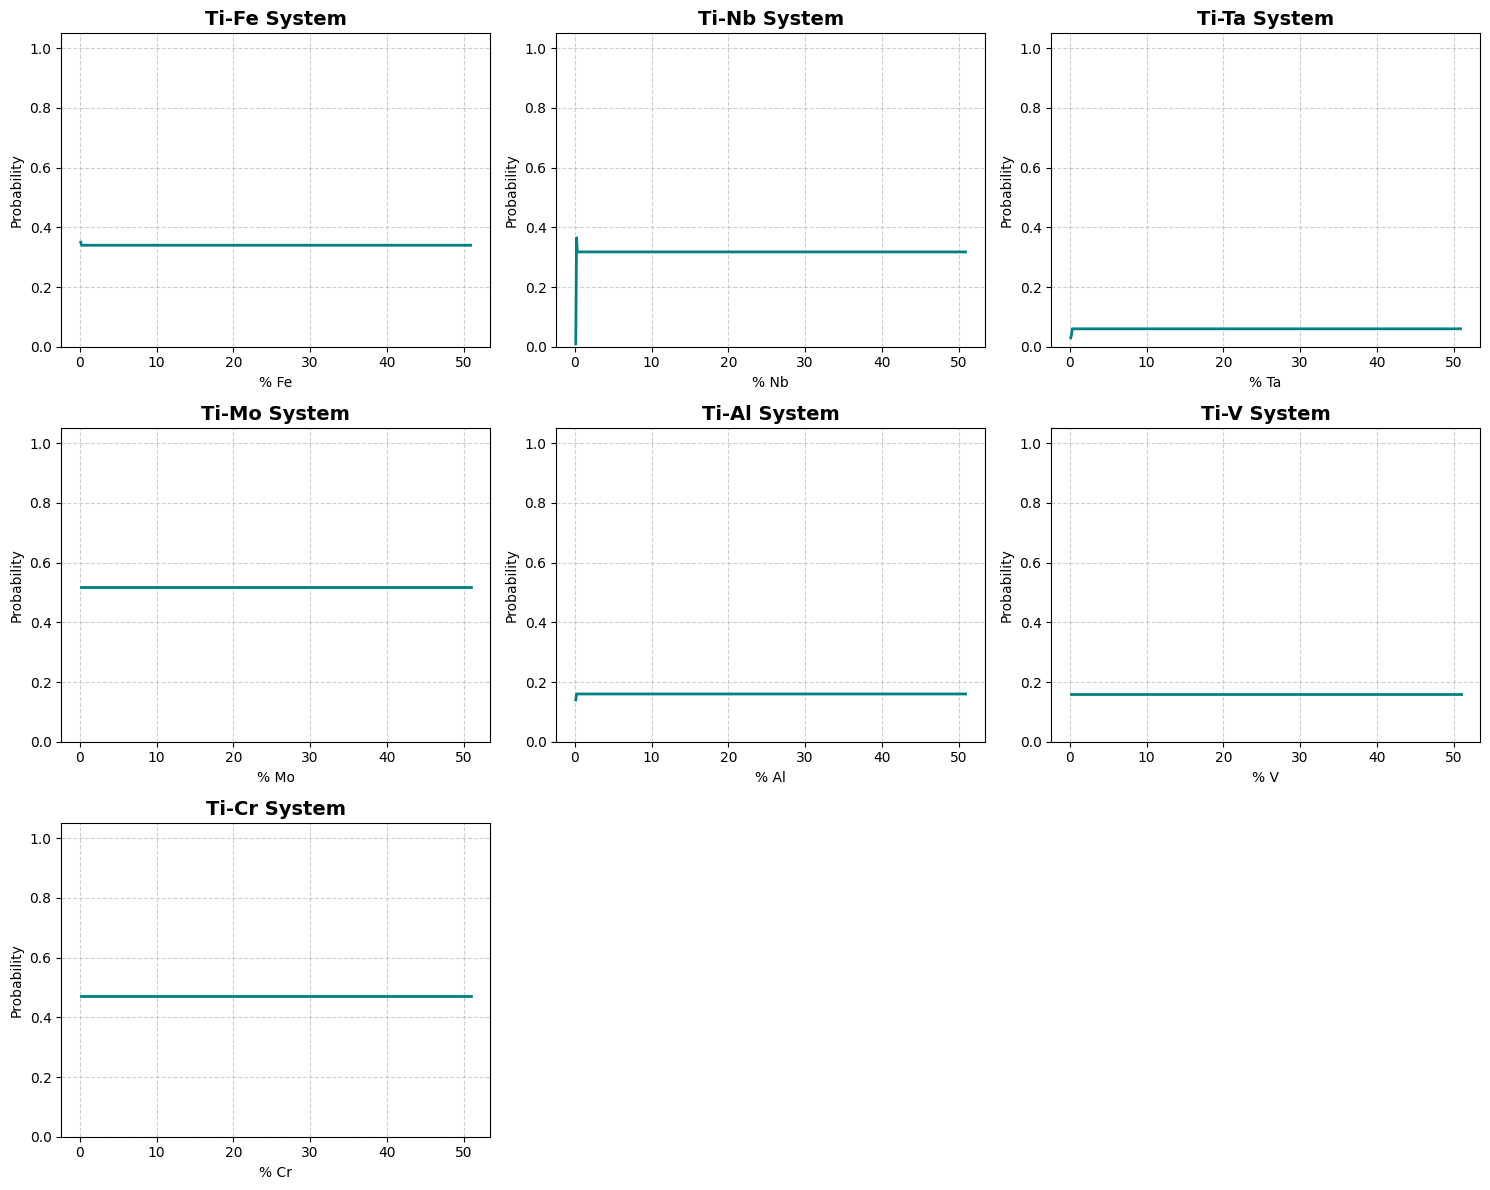

In [262]:
plt_el = ['Fe', 'Nb', 'Ta', 'Mo', 'Al', 'V', 'Cr']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() 

# 2. Iterate and Plot
for i, el in enumerate(plt_el):
    raw_data = synthetic_dict[el]
    scaled_data = scaler.transform(raw_data)
    y_proba = models0['rf'].predict_proba(scaled_data)[:, 1]
    
    # Plotting logic
    ax = axes[i]
    ax.plot(percentages, y_proba, color='teal', linewidth=2)
    ax.set_title(f"Ti-{el} System", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"% {el}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.05) # Probabilities stay between 0 and 1
    ax.grid(True, linestyle='--', alpha=0.6)

# 3. Clean up empty subplots
for j in range(len(plt_el), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

This is honestly really hard to interpret, as the probability does not appear to increase as the concentration of the element increases. If you take the base flat probability as the effectiveness of the stabilizer, then Mo, Cr, Fe and Nb are the strongest stabilizers. Then V, Ta, and Al are somewhat poor beta stabilizers.

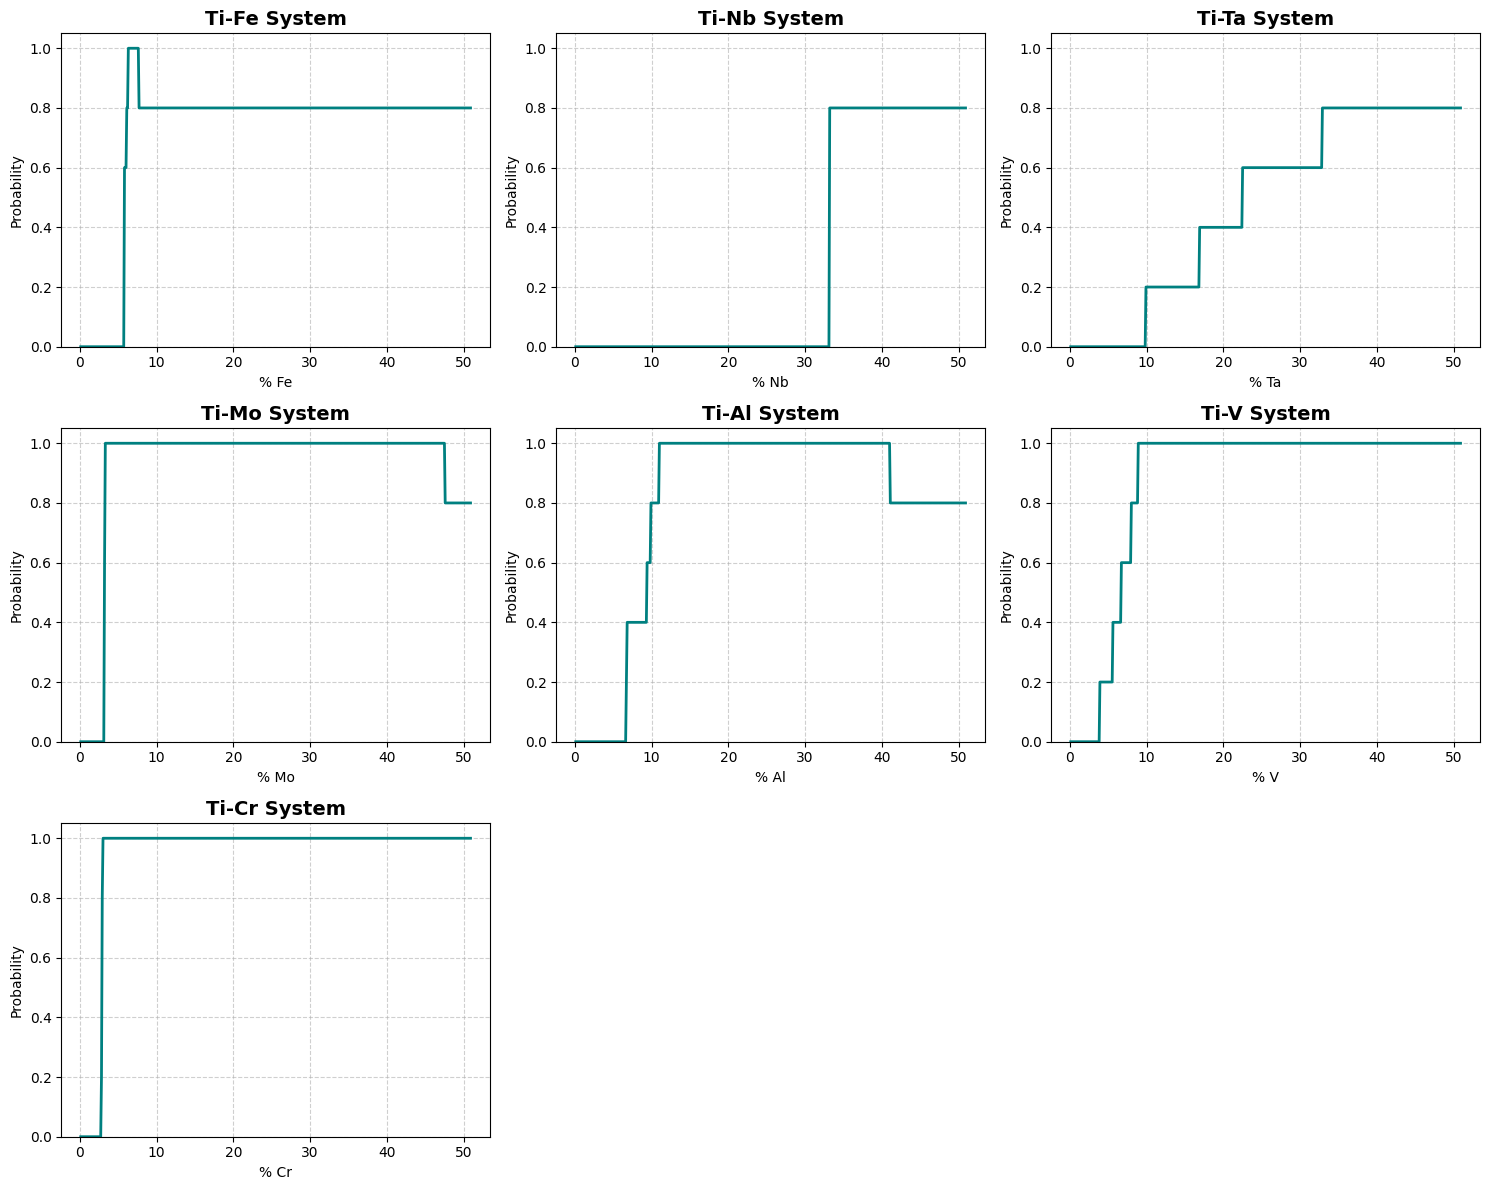

In [263]:
plt_el = ['Fe', 'Nb', 'Ta', 'Mo', 'Al', 'V', 'Cr']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() 

# 2. Iterate and Plot
for i, el in enumerate(plt_el):
    raw_data = synthetic_dict[el]
    scaled_data = scaler.transform(raw_data)
    y_proba = models0['knns'].predict_proba(scaled_data)[:, 1]
    
    # Plotting logic
    ax = axes[i]
    ax.plot(percentages, y_proba, color='teal', linewidth=2)
    ax.set_title(f"Ti-{el} System", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"% {el}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.05) # Probabilities stay between 0 and 1
    ax.grid(True, linestyle='--', alpha=0.6)

# 3. Clean up empty subplots
for j in range(len(plt_el), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The other models also had a similar sharp and unintelligible boundary as rf, except for logistic and knns. 

Chromium and Molybdenum are the best beta stabilizers according to knns. Fe, Al, and V are the next category of elements which are somewhat good beta stabilizers. Finally, Nb and Ta are beta stabilizers, but aren't quite as strong. Specifically Nb has an extremely sharp transition at around 32%, which is likely indication that there should be more data about Nb dopants within Ti alloys.

This dataset has less than 500 entries in it, and so I don't think there is a great predictor here.

### 1.3 Creating a Simpler Baseline

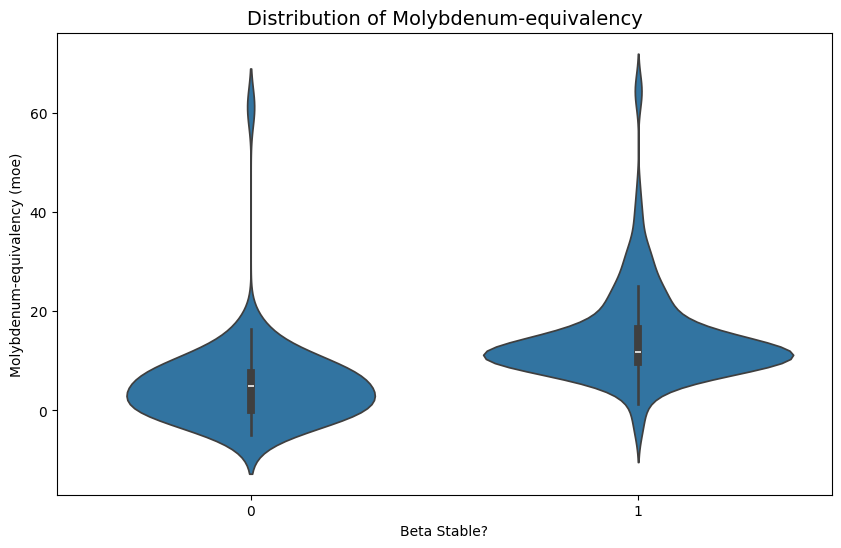

In [264]:
plt.figure(figsize=(10, 6))
sns.violinplot(data = df, y='moe', x='beta')
plt.title('Distribution of Molybdenum-equivalency', fontsize=14)
plt.xlabel('Beta Stable?')
plt.ylabel('Molybdenum-equivalency (moe)')
plt.show()

In [265]:
model_simple = LogisticRegression()
x = df[['moe']]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

# Create the new entry
new_data = {
    'Simple Logistic Model': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': "N/A"
    }
}

new_entry_df = pd.DataFrame(new_data)
results_df = pd.concat([results_df.T, new_entry_df], axis=1)

display(results_df.T)

,accuracy,precision,recall,f1_score,roc_auc
logistic,0.877193,0.865385,1.0,0.927835,0.874074
SVC,0.894737,0.882353,1.0,0.9375,0.859259
tree,0.894737,0.933333,0.933333,0.933333,0.838889
rf,0.929825,0.93617,0.977778,0.956522,0.925926
knns,0.877193,0.913043,0.933333,0.923077,0.875926
xgboost,0.894737,0.914894,0.955556,0.934783,0.927778
Simple Logistic Model,0.859649,0.911111,0.911111,0.911111,N/A


This model is worse than all the other models, which is good news, but the more complex models are only marginally better in f1_score. There is a strong argument that this simple model is therefore better because although it has a lower precision, accuracy, and recall, there is genuine scientific interpretability in the data. 

## 2 Regression

### 2.1 Training and evaluating regressors

In [266]:
target_cols = ["UTS", "DAR"]
df_cleaned = df.dropna(subset=target_cols)
x = compositions.loc[df_cleaned.index].values

y_1 = df_cleaned["UTS"].values
y_2 = df_cleaned["DAR"].values

In [267]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

kernel = 1.0 * RBF(length_scale=1.0)

models2 = {
    'linreg': LinearRegression(),
    'polyreg': make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=1.0)),
    'Random Forest Reg': RandomForestRegressor(n_estimators=100),
    'GPR': GaussianProcessRegressor(kernel=kernel, alpha = 0.1, random_state=42, normalize_y=True),
    "XGboost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
}

models2_5 = {
    'linreg': LinearRegression(),
    'polyreg': make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=1.0)),
    'Random Forest Reg': RandomForestRegressor(n_estimators=100),
    'GPR': GaussianProcessRegressor(kernel=kernel, alpha = 0.1, random_state=42, normalize_y=True),
    "XGboost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
}

x_1_train, x_1_test, y_1_train, y_1_test = train_test_split(x, y_1, train_size= 0.8, random_state= 68)
x_2_train, x_2_test, y_2_train, y_2_test = train_test_split(x, y_2, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
x1_train_scaled = scaler.fit_transform(x_1_train)
X1_test_scaled = scaler.transform(x_1_test)
x2_train_scaled = scaler.fit_transform(x_2_train)
X2_test_scaled = scaler.transform(x_2_test)

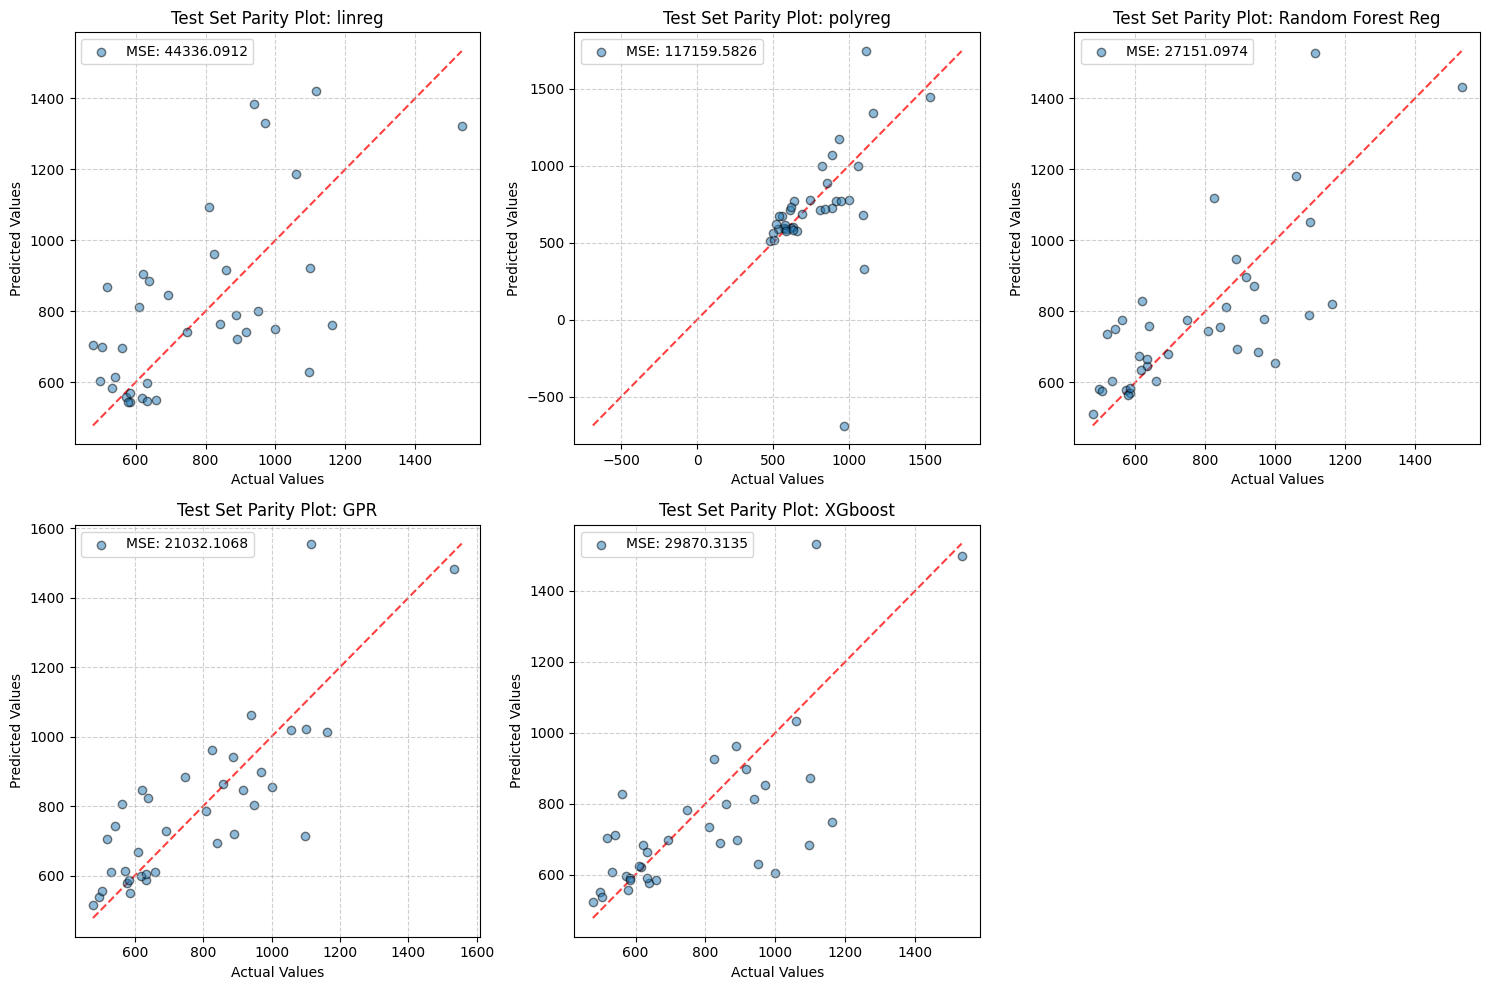

In [268]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models2.items()):
    model.fit(x_1_train, y_1_train)
    preds = model.predict(x_1_test)
    mse = mean_squared_error(y_1_test, preds)
    ax = axes[i]
    ax.scatter(y_1_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_1_test.min(), preds.min()]),
        np.max([y_1_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

if len(models2) < len(axes):
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

For the UTS, GPR is the best performing model with the lowest mean squared error of 21032, followed by Random Forest reg.

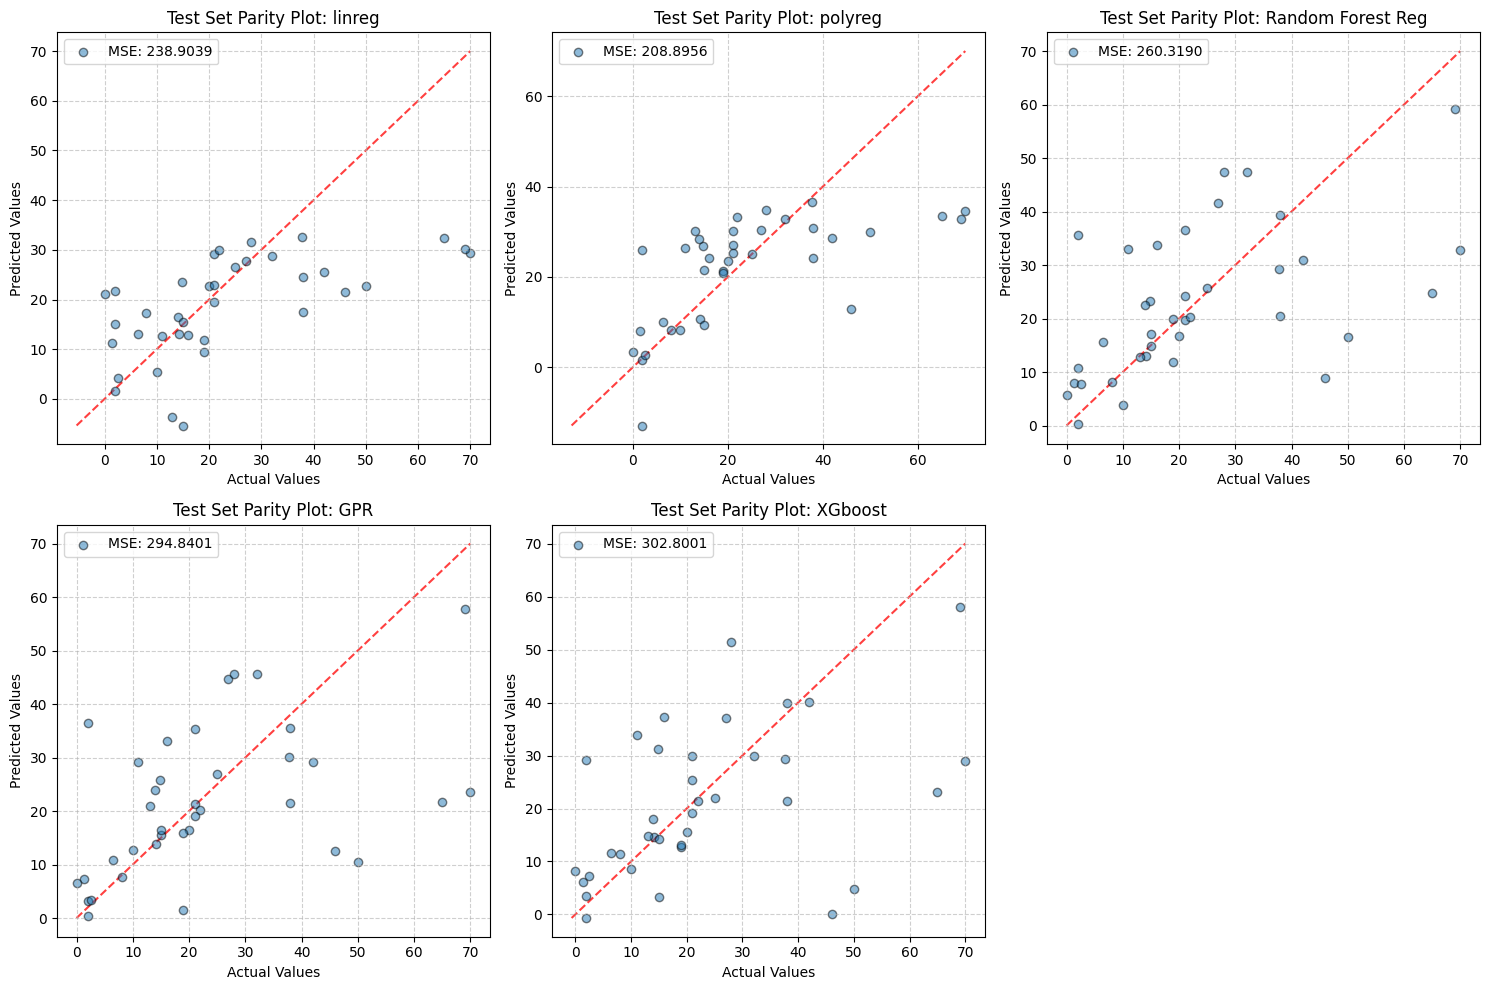

In [291]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models2_5.items()):
    model.fit(x_2_train, y_2_train)
    preds = model.predict(x_2_test)
    mse = mean_squared_error(y_2_test, preds)
    ax = axes[i]
    ax.scatter(y_2_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_2_test.min(), preds.min()]),
        np.max([y_2_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

if len(models2_5) < len(axes):
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

For ductility at rupture, polynomial regression was surprisingly the best predictor, with the lowest MSE of 208.9 followed by linreg.

In [270]:
y_combined = np.column_stack((y_1, y_2)) 

X_train, X_test, y_train, y_test = train_test_split(
    x, y_combined, train_size=0.8, random_state=68
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [271]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)
# considering y_train as defined as a two-column matrix (UTS and DAR)
grid_search.fit(X_train, y_train[:, 0])


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [272]:
from scipy.stats import pearsonr

results_list = []
for i, params in enumerate(grid_search.cv_results_['params']):
    # Extract the cross-validated (validation) RMSE (note: scores are negative).
    val_rmse = -grid_search.cv_results_['mean_test_score'][i]

    # Instantiate and train a new RandomForestRegressor with the candidate parameters on the full
    # training set.
    rf_candidate = RandomForestRegressor(**params)
    rf_candidate.fit(X_train, y_train[:, 0])

    y_pred_test = rf_candidate.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test[:, 0], y_pred_test))
    test_corr, _ = pearsonr(y_test[:, 0], y_pred_test)

    # Record all parameters and metrics in a dictionary.
    result_entry = params.copy()
    result_entry.update({
        'validation_rmse': val_rmse,
        'test_rmse': test_rmse,
        'test_corr': test_corr
    })
    results_list.append(result_entry)

# Create a Pandas DataFrame with all the results.
results_df = pd.DataFrame(results_list)

In [273]:
top_corr_indices = results_df['test_corr'].nlargest(3).index

print(f"{'Index':<8} | {'Test Corr':<10} | {'Parameters'}")
print("-" * 60)

for idx in top_corr_indices:
    # Access the specific parameter dict using the dataframe index
    params = grid_search.cv_results_['params'][idx]
    corr_val = results_df.loc[idx, 'test_corr']
    
    print(f"{idx:<8} | {corr_val:<10.4f} | {params}")

bottom_rmse_indices = results_df['test_rmse'].nsmallest(3).index
print(f"\n\n{'Index':<8} | {'Test RMSE':<10} | {'Parameters'}")
print("-" * 60)

for idx in bottom_rmse_indices:
    # Access the specific parameter dict using the dataframe index
    params = grid_search.cv_results_['params'][idx]
    rmse_val = results_df.loc[idx, 'test_rmse']
    
    print(f"{idx:<8} | {rmse_val:<10.4f} | {params}")

Index    | Test Corr  | Parameters
------------------------------------------------------------
31       | 0.7790     | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
3        | 0.7781     | {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
30       | 0.7750     | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


Index    | Test RMSE  | Parameters
------------------------------------------------------------
31       | 152.1099   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
30       | 152.3882   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
29       | 152.9966   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


The best models appear to have the parameters of max depth 5, min_samples_leaf 1, min_samples_split 5, and n_estimators of 50 and 100, as these are the models with the highest test corr and the lowest test RMSE.

In [274]:
models3 = {
    'Random Forest Reg 1': RandomForestRegressor(n_estimators=100, max_depth= 5, min_samples_split= 5, min_samples_leaf = 1),
    'Random Forest Reg 2': RandomForestRegressor(n_estimators=50, max_depth= 5, min_samples_split= 5, min_samples_leaf = 1)
}

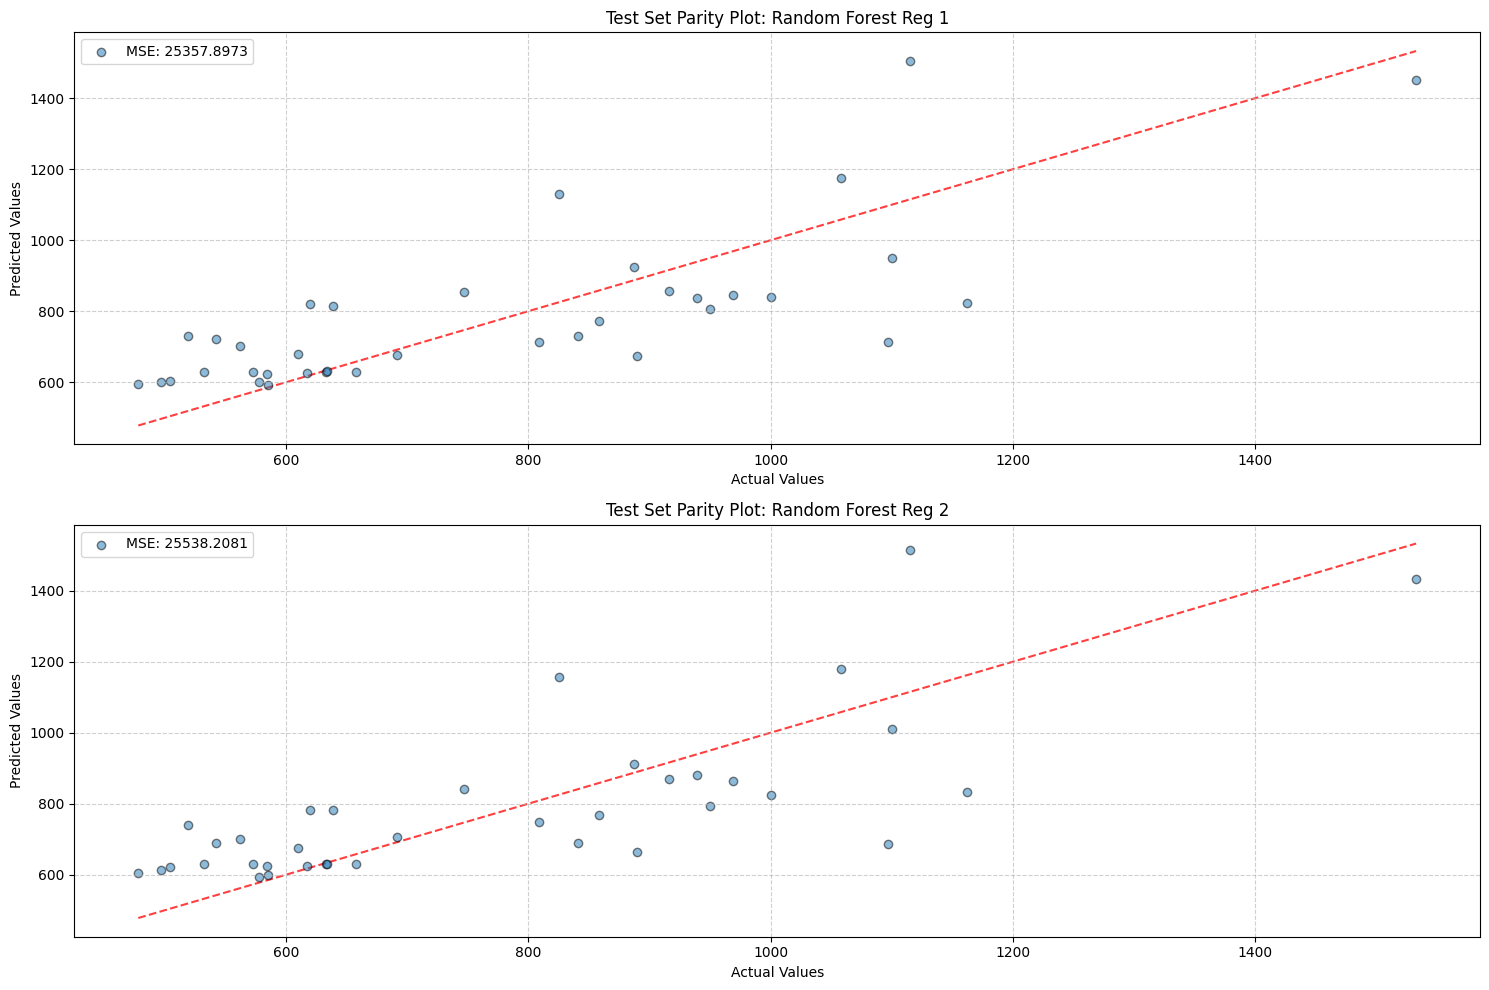

In [275]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models3.items()):
    model.fit(x_1_train, y_1_train)
    preds = model.predict(x_1_test)
    mse = mean_squared_error(y_1_test, preds)
    ax = axes[i]
    ax.scatter(y_1_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_1_test.min(), preds.min()]),
        np.max([y_1_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

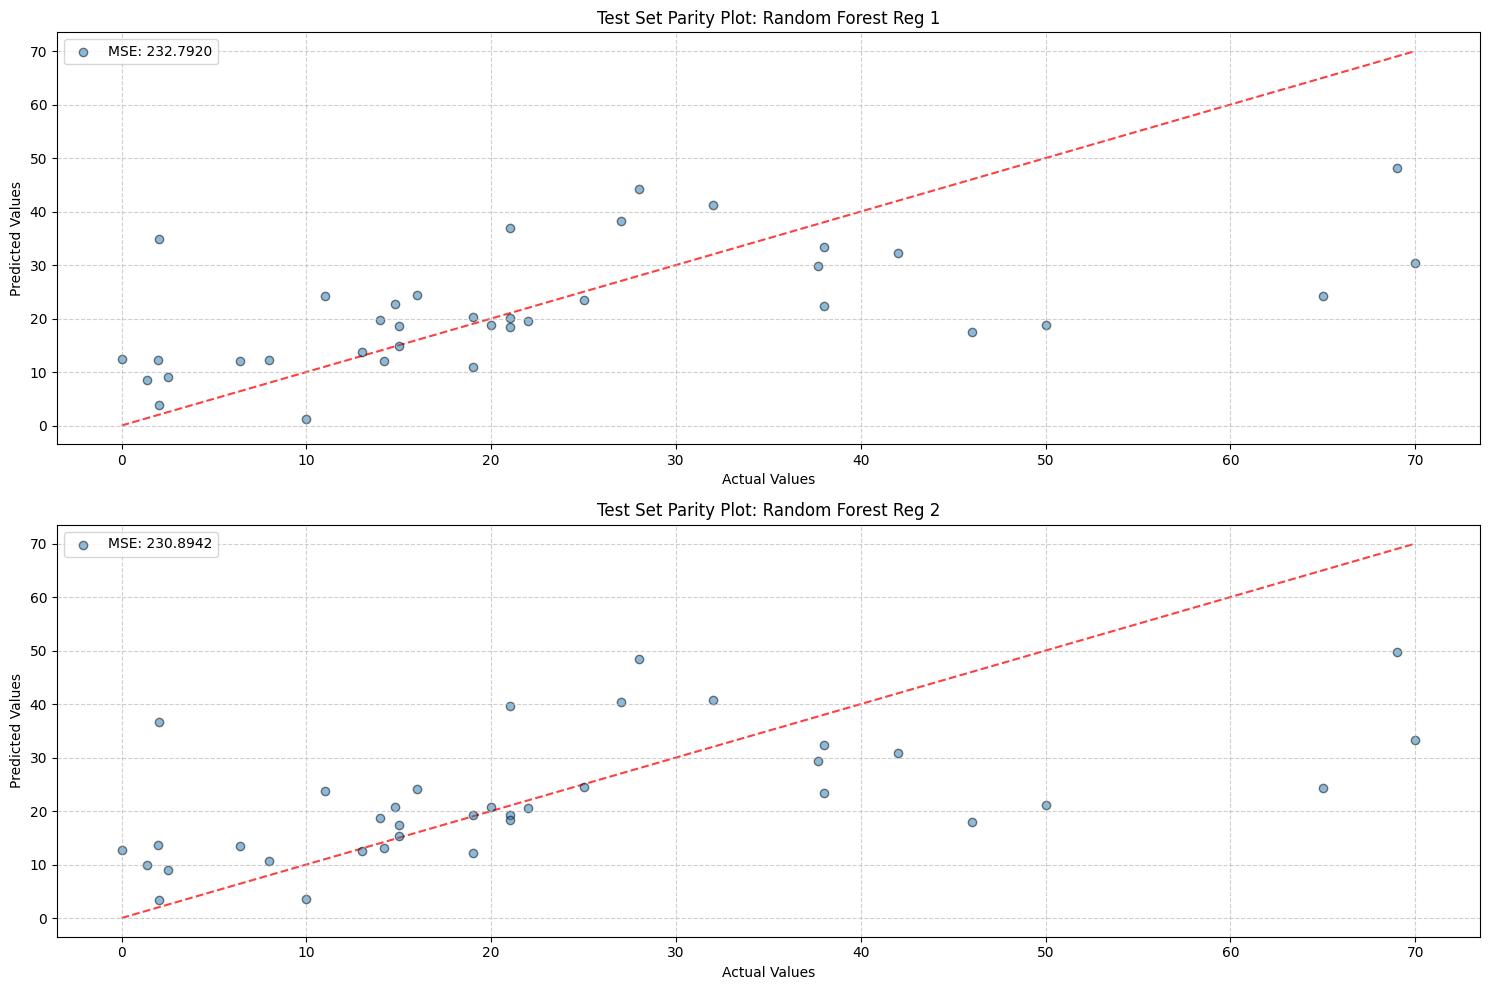

In [276]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models3.items()):
    model.fit(x_2_train, y_2_train)
    preds = model.predict(x_2_test)
    mse = mean_squared_error(y_2_test, preds)
    ax = axes[i]
    ax.scatter(y_2_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_2_test.min(), preds.min()]),
        np.max([y_2_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

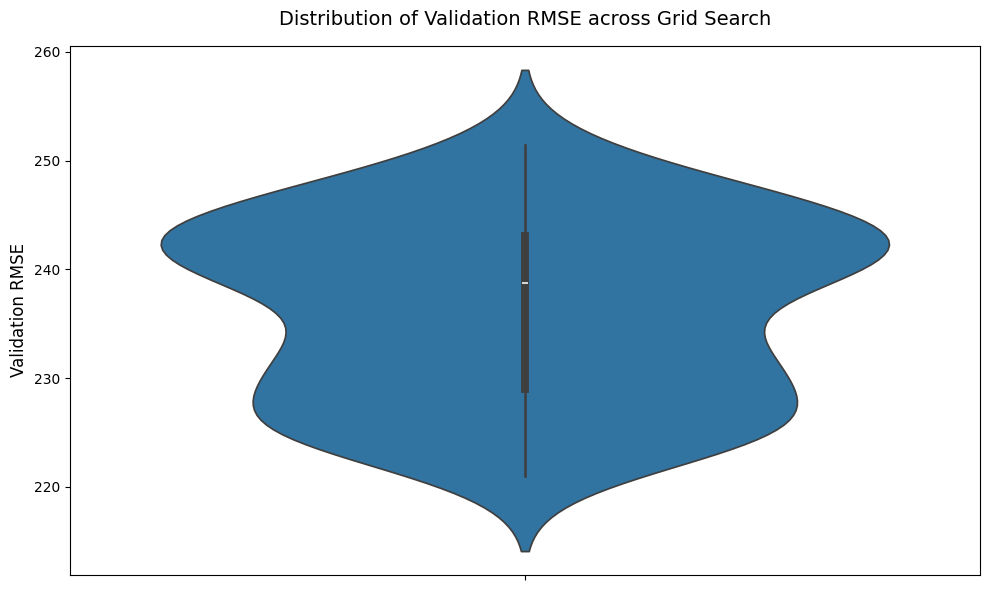

In [277]:
plt.figure(figsize=(10, 6))

sns.violinplot(y=results_df['validation_rmse'])
plt.title('Distribution of Validation RMSE across Grid Search', fontsize=14, pad=15)
plt.ylabel('Validation RMSE', fontsize=12)
plt.tight_layout()
plt.show()

Although there is some variation in the validation_rmse or validation loss as a function of the hyperparameter used, the difference is only about 10% of the total rmse, so there isn't a significant amount of variability. This is likely because most of the grid searched hyperparameter chosen are already within a reasonable range.

The performance of the model previously had a test RMSE of 27151 for the UTS and 264 for DAR. Both of these models improved on the initial performance (RFreg 1: 25358, 233) (RFreg 2: 25538, 231), but did not improve on the best models. Tuning hyperparameters did improve the performance of the models, but not as significantly as choosing the best model to use. 

## 3 Active Learning for alloy design

### 3.1 Proposing an Objective

In [ ]:
DOPANTS = [
    "Fe", "Zr", "Nb", "Sn", "Ta",
    "Mo", "Al", "V", "Cr", "Cu",
    "Hf", "Mn", "W", "Ni", "Sc", "Si"
]
MAX_DOPANTS = 4

def convert_composition(Ti, Fe, Zr, Nb, Sn, Ta, Mo, Al, V, Cr, Cu, Hf, Mn, W, Ni, Sc, Si):
    """This function converts the composition of the alloy (input space) and normalizes 
    it, ensuring that we can create an alloy with up to 4 dopants."""
    
    # converting the input dopants into an array
    dopants = np.array([Fe, Zr, Nb, Sn, Ta, Mo, Al, V, Cr, Cu, Hf, Mn, W, Ni, Sc, Si])

    # zeroing out all the "less important" dopants
    sorter = np.argsort(dopants)
    threshold = dopants[sorter[-MAX_DOPANTS]]
    dopants = dopants * (dopants >= threshold).astype(float)

    # normalize the concentration so that the concentration of all dopants
    # does not exceed the term (1 - Ti), where 'Ti' is the molar ratio of
    # titanium in the alloy.
    if np.sum(dopants) > 0:
        dopants = (1 - Ti) * dopants / np.sum(dopants)

    # returns a concentration in the form of a dictionary
    return {
        "Ti": Ti,
        **dict(zip(DOPANTS, dopants))
    }

# defining the search space
pbounds = {
    "Ti": (0.6, 1.0),
    **{element: (0.0, 1.0) for element in DOPANTS}
}    

In [346]:
uts_model = models2['Random Forest Reg']
# GPR returns to zero, so although it has the lowest MSE, I will be using Random Forest Reg. 
# AKA I couldn't find sucess with GPR
dar_model = models2_5['Random Forest Reg'] 
# This is not the best predictor, but I don't like that linear and polynomial fit are favored 
# to overpredict higher DARS Random Forest Reg is the best model which has balanced error 
# throughout the domain of DARS
beta_model = models0['rf']
# This is actually the best predictor which is good

def objective_fn(Ti, Fe, Zr, Nb, Sn, Ta, Mo, Al, V, Cr, Cu, Hf, Mn, W, Ni, Sc, Si):
    """
    This function defines an objective function for your Bayesian optimization strategy.
    Specifically, we take a composition, normalize it using the function above,
    then use the ML models to predict the UTS, the DAR, and whether the alloy will
    lead to the beta phase. However, this is a multi-objective optimization strategy.
    You should propose an objective, i.e., the one-dimensional quantity we are trying to optimize.
    """
    
    # normalize the composition and make it as an input
    composition = convert_composition(Ti, Fe, Zr, Nb, Sn, Ta, Mo, Al, V, Cr, Cu, Hf, Mn, W, Ni, Sc, Si)
    dopants = np.array(list(composition.values()))

    # the active learning loop gives us one data point at a time,
    # so we have to reshape it as a 2D matrix
    X_candidate = dopants.reshape(1, -1)

    # Obtain "ground truth" predictions
    pred_uts = uts_model.predict(X_candidate)[0]
    pred_dar = dar_model.predict(X_candidate)[0]
    pred_beta = beta_model.predict(X_candidate)[0]

    # Here, you should propose an objective to be maximized
    # based on the properties above. It will likely be a function
    # of pred_beta, pred_uts, and pred_dar, but it can also
    # be a function of 'dopants' if you wish.
    
    # Example objective: Weighted sum (adjust weights based on priority)
    w1 = 30/1200*1200/20
    w2 = 30/25*1200
    w3 = 1/100*1200
    objective = (w1 * pred_uts * pred_dar) + (w2 * pred_dar) + (w3 * pred_beta)
    # I want the model to prioritize beta to be stabilized and then some maximum of toughness
    # UTS goes from 0-1400, and needs to be 1200 
    # DAR goes from 0-70, and needs to be 25, and positive. We check the positive by multiplying pred_dar and dividing 20
    # Beta is a binary, but I want it to be scaled to be much less significant (1000xs less significant than other factors)
    
    return objective

### 3.2 Performing an Optimization

In [352]:
from bayes_opt import BayesianOptimization

optimizer = BayesianOptimization(
    f=objective_fn,
    pbounds=pbounds,
    verbose=2,
)

optimizer.maximize(init_points=100, n_iter=500)

|   iter    |  target   |    Ti     |    Fe     |    Zr     |    Nb     |    Sn     |    Ta     |    Mo     |    Al     |     V     |    Cr     |    Cu     |    Hf     |    Mn     |     W     |    Ni     |    Sc     |    Si     |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | 24095.355 | 0.7734818 | 0.2471554 | 0.9102421 | 0.7679120 | 0.5025422 | 0.6306090 | 0.2267886 | 0.6047678 | 0.1233969 | 0.3709961 | 0.5858214 | 0.3576854 | 0.6302836 | 0.5361036 | 0.7441930 | 0.6448297 | 0.4600984 |
| 2         | -38610.82 | 0.7367517 | 0.8094741 | 0.9476560 | 0.1093152 | 0.0322344 | 0.7889020 | 0.7204563 | 0.6866280 | 0.6504881 | 0.0584065 | 0.2064173 | 0.2318971 | 0.8337370 | 0.0301554 | 0.4557310 | 0.6542008 | 0.0919399 |
| 3         | 15779.018 | 0.9223876 | 0.9307411 | 0.3544409 | 0.2024629 | 0.3810

In [353]:
records = []
for res in optimizer.res:
    params = res["params"]  # this is the input composition
    objective = res["target"]  # this is the objective you defined

    # converting the composition into something that we can use with the ML model
    composition = convert_composition(**params)
    dopants = np.array(list(composition.values()))
    X_candidate = dopants.reshape(1, -1)

    # Get the surrogate predictions.
    pred_uts = uts_model.predict(np.array(X_candidate))[0]
    pred_dar = dar_model.predict(np.array(X_candidate))[0]
    pred_beta = beta_model.predict(np.array(X_candidate))[0]

    # Record the results.
    record = {
        **composition,
        'UTS': pred_uts,
        'DAR': pred_dar,
        'Beta': pred_beta,
        'objective': objective
    }
    records.append(record)

results_df = pd.DataFrame(records)

In [358]:
top_5_results = results_df.sort_values(by='objective', ascending=False).drop_duplicates().head()

elements = results_df.columns[:-4] 
non_zero_elements = [col for col in elements if (top_5_results[col] != 0).any()]

target_cols = ['UTS', 'DAR', 'Beta', 'objective']

final_cols = non_zero_elements + target_cols
display(top_5_results[final_cols])

,Ti,Sn,Ta,Mo,Al,W,Sc,UTS,DAR,Beta,objective
584,0.6,0.000000,0.100000,0.100000,0.100000,0.0,0.10000,1212.413,28.637700,1,93331.367655
337,0.6,0.000000,0.106060,0.106060,0.106060,0.0,0.08182,1196.034,28.793500,1,93131.647468
320,0.6,0.000000,0.100000,0.100000,0.100000,0.1,0.00000,1216.321,28.513117,1,93092.541866
555,0.6,0.093073,0.102309,0.102309,0.102309,0.0,0.00000,1201.714,28.704300,1,93087.730755
493,0.6,0.091425,0.102858,0.102858,0.102858,0.0,0.00000,1201.714,28.704300,1,93087.730755


Above are the best alloys. There is a direct tradeoff between UTS and DAR, but all the alloys have stable beta. After a lot of trial and error, 4 alloys which statisfied the criteria was found

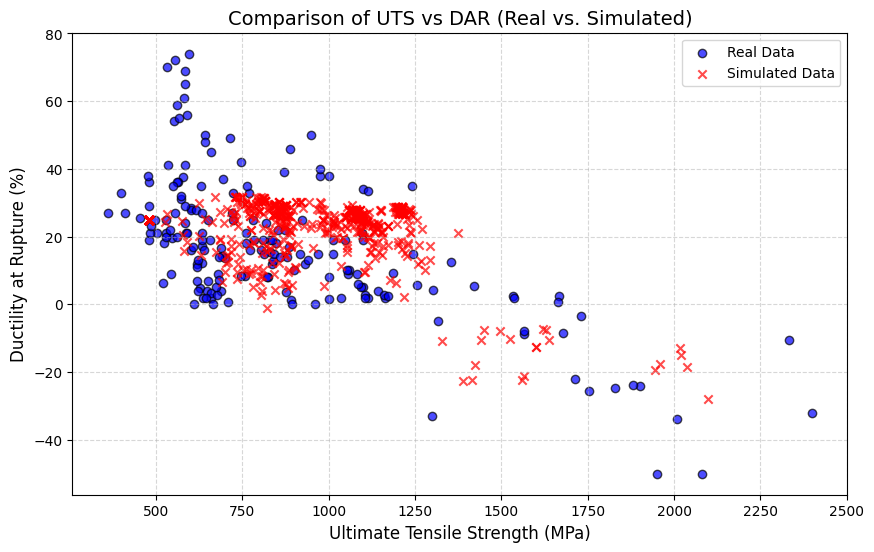

In [359]:
x_real = df['UTS']
y_real = df['DAR']

x_sim = results_df['UTS']
y_sim = results_df['DAR']  

plt.figure(figsize=(10, 6))
plt.scatter(x_real, y_real, color='blue', label='Real Data', alpha=0.7, edgecolor='k')
plt.scatter(x_sim, y_sim, color='red', label='Simulated Data', alpha=0.7, marker='x')
plt.title('Comparison of UTS vs DAR (Real vs. Simulated)', fontsize=14)
plt.xlabel('Ultimate Tensile Strength (MPa)', fontsize=12)
plt.ylabel('Ductility at Rupture (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Show the plot
plt.show()

Achieving the target UTS turned out to be much harder than achieving the target DARS. It may have been interesting to give the objective function a more complex fit to greater incentivize increasing the UTS over DARS. Still with this, I could not push the pareto front nor achieve the intended objective. There is in fact only really one alloy which surpassed the criteria, which was in the original dataset. 

I've spent probably 2 hours on this problem alone, so I am a bit stuck on how to try and create an objective function which pushes the Pareto front beyond the original dataset. A large issue is that the data is converging around 1200 UTS and 20% ductility and failing to explore to greener pastures. 



### 3.3 Discussing the Results

Ta, Mo, and Al were used in 1:1:1 stoichiometric ratios with Sc, W, and Sn additions. Of these, only Mo and Al make sense as these are commonly used alloying elements. Mo is a go to beta stabilizer, and Al forms strong Ti-Al intermetallics.

In [360]:
from sklearn.metrics.pairwise import cosine_similarity


data_v = df[DOPANTS]
results_v = results_df[DOPANTS]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_v)
results_scaled = scaler.transform(results_v)

similarity_matrix = cosine_similarity(results_scaled, data_scaled)

best_match_indices = similarity_matrix.argmax(axis=1)
results_df['most_similar_idx'] = best_match_indices
results_df['similarity_score'] = similarity_matrix.max(axis=1)

KeyError: "None of [Index(['Fe', 'Zr', 'Nb', 'Sn', 'Ta', 'Mo', 'Al', 'V', 'Cr', 'Cu', 'Hf', 'Mn',\n       'W', 'Ni', 'Sc', 'Si'],\n      dtype='object')] are in the [columns]"